<a href="https://colab.research.google.com/github/Kohei-200/math/blob/main/simulation/Audio_Effects1_LTI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Time-Invariance

In [292]:
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import scipy

### Examples

`Linear` but `not TI`



- AM modulation ($y[n] = x[n]cos(2pi\omega_cn$))
- Time Stretch ($y(t) = x(\alpha t$))
- DTFT

`not Linear` and `not TI`

- Envelope Detection ($y[n] = |x[n]|^2 * h[n]$)
- Clipping $y[n] = \begin{cases}
x[n], x[n] \le M \\
0, otherwise
\end{cases}$

#### **Linear and TI**
- Second Derivative ($y(t) = \frac{d^2}{dt^2}x(t)$)

### Linearity

$$\mathcal{H}\{ax_1 + bx_2\} = a\mathcal{H}\{x_1\} + b\mathcal{H}\{x_2\}$$
scaling the input scales the output by the same amount, and response to a sum of signals equals the sum of the responses.
### Time-invariance
$$\mathcal{H}\{x[n - n_0]\} = y[n-n_0]$$
delaying the input only delayes the output by the same amount.

### LTI effects (this note explores)
- EQ (non-dynamic)
- Audio crossover
- Delay/echo (static)
- Reverb
### non-LTI effects (not explored here)
`Nonlinear`
- Distortion / overdrive / saturation / clipping
- Compressor / limiter / gate
- Bitcrushing

`Time-varying`
- Chorus / flanger
- Phaser
- Vibrato
- (Auto-)Wah / envelope filter
- Pitch shift / time-stretch
- De-esser
- Sidechain (noise gates)

### Audio Sources

In [293]:
# audio sample MTG sms-tools
!git clone https://github.com/MTG/sms-tools-materials.git

fatal: destination path 'sms-tools-materials' already exists and is not an empty directory.


In [294]:
# Impulse response
impulse_response =  "/content/sms-tools-materials/sounds/impulse-response.wav"

# White noise
sr = 48000
sf.write("white_noise.wav",  np.random.uniform(low=-0.2, high=0.2, size=sr), sr)
white_noise = "white_noise.wav"

# Chirp
dur = 2
N = int(sr*dur)
t = np.arange(N) / sr
sf.write("chirp.wav",  scipy.signal.chirp(t, f0=20, f1=8000, t1=dur, method="linear"), sr)
chirp_lin = "chirp.wav"

# Sine
sine_490 = "/content/sms-tools-materials/sounds/sine-490.wav"


audios = {"impulse_response":impulse_response,
          "white_noise": white_noise,
          "chirp_lin": chirp_lin, "sine_490": sine_490}

plot funcs

In [295]:
def plot_audios(effect_name, audios: dict):

   for name, (audio_path, audio_mod_path) in audios.items():
        x, sr = sf.read(audio_path)
        x_mod, sr_mod = sf.read(audio_mod_path)

        time = np.linspace(0, len(x) / sr, num=len(x))
        time_mod = np.linspace(0, len(x_mod) / sr_mod, num=len(x_mod))

        print(f"{name} — original")
        ipd.display(ipd.Audio(x, rate=sr))
        print(f"{name} — {effect_name}")
        ipd.display(ipd.Audio(x_mod, rate=sr_mod))

        fig, axes = plt.subplots(2, 1, figsize=(5, 3), dpi=100, sharex=True)

        axes[0].set_title(f"{name} (original)")
        axes[0].plot(time, x, linewidth=0.5)

        axes[1].set_title(f"{name} ({effect_name})")
        axes[1].plot(time_mod, x_mod, linewidth=0.5)

        axes[1].set_xlabel("Time (s)")
        plt.tight_layout()
        plt.show()

In [308]:
def overlay_spectra(effect_name, audios: dict, scale = "log"):

    for name, (audio_path, audio_mod_path) in audios.items():
        x, sr = sf.read(audio_path)
        x_mod, sr_mod = sf.read(audio_mod_path)

        # FFT magnitude (rfft since audio is real-valued)
        X = np.fft.rfft(x)
        X_mod = np.fft.rfft(x_mod)
        freqs = np.fft.rfftfreq(len(x), d=1/sr)
        freqs_mod = np.fft.rfftfreq(len(x_mod), d=1/sr_mod)

        # magnitude in dB, with a floor to avoid log(0)
        mag_db = 20 * np.log10(np.abs(X) + 1e-12)
        mag_mod_db = 20 * np.log10(np.abs(X_mod) + 1e-12)

        fig, ax = plt.subplots(figsize=(6, 3), dpi=100)
        ax.plot(freqs, mag_db, label="original", alpha=0.7, linewidth=0.7)
        ax.plot(freqs_mod, mag_mod_db, label=f"{effect_name}", alpha=0.7, linewidth=0.7)

        ax.set_title(name)
        ax.set_xlabel("Freq (Hz)")
        ax.set_ylabel("Mag (dB)")
        ax.legend()

        if scale == "log":
            ax.set_xscale("log")
            ax.set_xlim(20, sr/2)
        ax.grid(True, which="both", alpha=0.2)
        plt.tight_layout()
        plt.show()

### EQ

global:
- `sample rate`($f_s$)

params:
- `center freq`($f_0$)
- `quality` ($Q = \frac{f_0}{BW}$ $BW$: Band Width)
- `gain_db`

values:
- `peak/shelf gain` ($A = 10 ^ {\text{gain_db}/40}$
- `angular frequency` ($\omega_0 = 2\pi f_0/f_s$)
- `"damping" factor` ($\alpha = \frac{sin(\omega_0)}{2Q}$)

6 coefficients (order 2 / biquad):
- Zeros: `feedforward (numerator) coefficients` ($b_0, b_1, b_2$)
- Poles: `feedback (denominator) coefficients` ($a_0, a_1, a_2$)

output (normalized, $a_0 = 1$):
- $y[n]=b_0x[n]+b_1x[n−1]+b_2x[n−2]-a_1y[n−1]-a_2y[n−2]$

z-plane:
- $H(z) = \frac{b_0 + b_1z^{-1} + b_2z^{-2}}{1 + a_1z^{-1} + a_2z^{-2}}$

In [297]:
def peaking_EQ_biquad(f0: float, # center frequency, Hz
                      Q: float,  # (bandwidth control)
                      gain_db: float, # boost (+) or cut (-) at f0, in dB
                      fs: float
                      ) -> tuple[np.ndarray, np.ndarray]:
    """
    Return:
    b : np.ndarray, shape (3,) — feedforward coefficients [b0, b1, b2]
    a : np.ndarray, shape (3,) — feedback coefficients [1, a1, a2]
    """
    A      = 10 ** (gain_db / 40)
    omega0 = 2 * np.pi * f0 / fs
    alpha  = np.sin(omega0) / (2 * Q)

    b0 = 1 + alpha*A
    b1 = -2*np.cos(omega0)
    b2 = 1 - alpha*A
    a0 = 1 + alpha/A
    a1 = -2*np.cos(omega0)
    a2 = 1 - alpha/A

    # normalize
    b = np.array([b0, b1, b2]) / a0
    a = np.array([1, a1/a0, a2/a0])

    return b, a

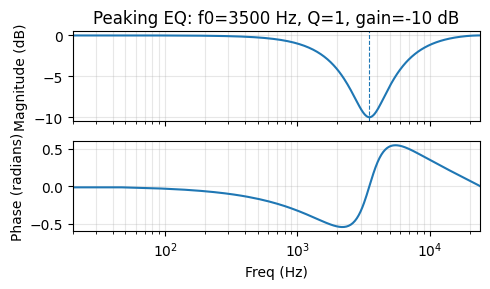

In [302]:
f0, Q, gain_db, fs = 3500, 1, -10, 48000
b, a = peaking_EQ_biquad(f0, Q, gain_db, fs)

w, h = scipy.signal.freqz(b, a, fs=fs)

mag_db = 20 * np.log10(np.abs(h) + 1e-12)
phase = np.angle(h)

fig, axes = plt.subplots(2, 1, figsize=(5, 3), dpi=100, sharex=True)

axes[0].plot(w, mag_db)
axes[0].set_ylabel("Magnitude (dB)")
axes[0].set_title(f"Peaking EQ: f0={f0} Hz, Q={Q}, gain={gain_db} dB")
axes[0].axvline(f0, linestyle="--", linewidth=0.8)
axes[0].set_xscale("log")
axes[0].set_xlim(20, fs/2)
axes[0].grid(True, which="both", alpha=0.3)

axes[1].plot(w, phase)
axes[1].set_ylabel("Phase (radians)")
axes[1].set_xlabel("Freq (Hz)")
axes[1].set_xscale("log")
axes[1].set_xlim(20, fs/2)
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

In [299]:
def apply_EQ(audios):

    output = {}
    for name, audio in audios.items():
        x, sr = sf.read(audio)

        f0, Q, gain_db = 1000, 1, -10
        b, a = peaking_EQ_biquad(f0, Q, gain_db, sr)
        x_filtered = scipy.signal.lfilter(b, a, x)

        sf.write(f"{name}_EQd.wav", x_filtered, sr)
        output[name] = (audio, f"{name}_EQd.wav")
    return output

In [300]:
output = apply_EQ(audios)

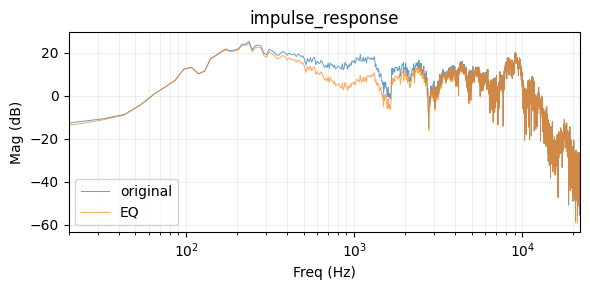

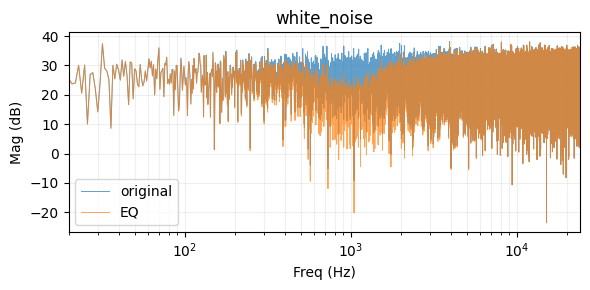

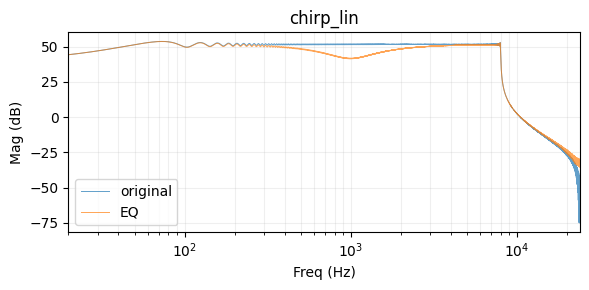

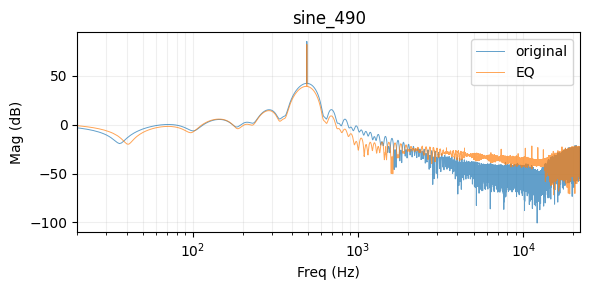

In [309]:
overlay_spectra("EQ", output)